# Model A: K-Means Clustering with Classifier-Based Routing

K-means clustering to extract the dominant color from a product image. Each image is first routed through the Stage 1 ResNet-18 classifier (from notebook 06) to predict its product type (`swatch`, `bullet_lipstick`, `liquid_lipstick`, `closed`), then k-means is run with a **category-specific optimal k** determined by the elbow method per group.

**Why per-category clustering helps:** a bullet lipstick, a swatch, and a liquid lipstick have fundamentally different visual structure. Running one global k across all types forces clusters to span packaging and backgrounds in ways that hurt color accuracy. Grouping by predicted type lets k-means focus on the relevant color variation within each category.

**Evaluation:** Delta E CIE 2000 against manually annotated ground-truth LAB values (~198 images). Two extraction strategies are compared per category: *peak* (largest cluster by pixel count) and *mean* (average across non-background clusters), with near-black and near-white clusters filtered as packaging/background noise.

**Comparison:** Model A v2 (k-means, best strategy per type) is benchmarked head-to-head against Model C (segmentation) on the same images. Result: Model A wins for swatches (ΔE ≈ 2.16 vs 3.15), while Model C dominates for bullet, liquid, and closed types. The production pipeline uses a hybrid of both.

**Context:** K-means performs well when the target color dominates the image — as it does for swatches. It fails for bullet and liquid shots where packaging pixels outnumber lipstick pixels; without knowing *where* the color is, clustering cannot fix this. This diagnosis motivates Model C's segmentation approach.

**Inputs:** `data/annotations/labels.csv`, `data/img/annotation_sample/`, `data/img/annotation_sample_closed/`, `models/resnet18_classifier_al.pth`, `models/unet_segmenter.pth`, `models/unet_segmenter_other.pth`

**Outputs:** analysis and visualizations only (no files written)

# Libraries

In [1]:
import os
import sys
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.cluster.vq
from PIL import Image
from skimage.color import rgb2lab, lab2rgb, deltaE_ciede2000
import torch
import torch.nn as nn
from torchvision import models, transforms
from sklearn.cluster import KMeans
warnings.filterwarnings('ignore')

# Setup

In [2]:
BASE       = os.path.abspath('..') if os.path.basename(os.getcwd()) == 'notebooks' else os.getcwd()
IMG_SAMPLE = os.path.join(BASE, 'data', 'img', 'annotation_sample')
IMG_CLOSED = os.path.join(BASE, 'data', 'img', 'annotation_sample_closed')
IMG_DIRS   = [IMG_SAMPLE, IMG_CLOSED]
ANN_DIR    = os.path.join(BASE, 'data', 'annotations')
MODELS_DIR = os.path.join(BASE, 'models')

RANDOM_SEED = 42
CLASSES     = ['bullet_lipstick', 'liquid_lipstick', 'other', 'swatch']
DEVICE      = 'mps' if torch.backends.mps.is_available() else 'cuda' if torch.cuda.is_available() else 'cpu'

CIELAB_WHITE          = np.array([100, 0, 0])
CIELAB_BLACK          = np.array([0, 0, 0])
BLACK_WHITE_THRESHOLD = 10

def find_image(img_name):
    for d in IMG_DIRS:
        p = os.path.join(d, img_name)
        if os.path.exists(p):
            return p
    return None

print(f'device: {DEVICE}')

device: mps


# Data

## Data

Load the annotated images from notebook 3. These ~198 images have resolved disk filenames and ground-truth LAB values from manual annotation: the same set used to evaluate Model C.

In [3]:
labels_df = pd.read_csv(os.path.join(ANN_DIR, 'labels.csv'))
labels_df = labels_df[labels_df['img_name_disk'].notna()].reset_index(drop=True)
labels_df['img_path'] = labels_df['img_name_disk'].apply(find_image)
labels_df = labels_df[labels_df['img_path'].notna()].reset_index(drop=True)

print(f'{len(labels_df)} images on disk')
print(labels_df['label'].value_counts().to_string())
print(f'\n{labels_df["true_L"].notna().sum()} images have ground-truth LAB')

198 images on disk
label
swatch             89
bullet_lipstick    55
liquid_lipstick    38
other              16

178 images have ground-truth LAB


In [4]:
# Stage 1 — load classifier and predict product type for each image

val_tf = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])

def build_classifier(num_classes=4):
    m = models.resnet18(weights=None)
    m.fc = nn.Linear(m.fc.in_features, num_classes)
    return m

def predict_class(model, img_path, device):
    img = Image.open(img_path).convert('RGB')
    with torch.no_grad():
        probs = torch.softmax(
            model(val_tf(img).unsqueeze(0).to(device)), dim=1
        ).squeeze().cpu().numpy()
    return CLASSES[probs.argmax()], float(probs.max())

clf_ckpt = os.path.join(MODELS_DIR, 'resnet18_classifier_al.pth')
clf = build_classifier().to(DEVICE)
clf.load_state_dict(torch.load(clf_ckpt, map_location=DEVICE)['model_state_dict'])
clf.eval()

labels_df['pred_label']      = None
labels_df['pred_confidence'] = None
for i, row in labels_df.iterrows():
    pred, conf = predict_class(clf, row['img_path'], DEVICE)
    labels_df.at[i, 'pred_label']      = pred
    labels_df.at[i, 'pred_confidence'] = conf

print('Predicted label distribution:')
print(labels_df['pred_label'].value_counts().to_string())
acc = (labels_df['pred_label'] == labels_df['label']).mean()
print(f'\nRouting accuracy vs ground-truth label: {acc:.1%}')

Predicted label distribution:
pred_label
swatch             89
bullet_lipstick    54
liquid_lipstick    39
other              16

Routing accuracy vs ground-truth label: 99.5%


# Optimal k per Category: Elbow Method

Different product types have different visual complexity, so the best k likely differs by category. The elbow method is run separately on each predicted category to find the optimal number of clusters for that group.

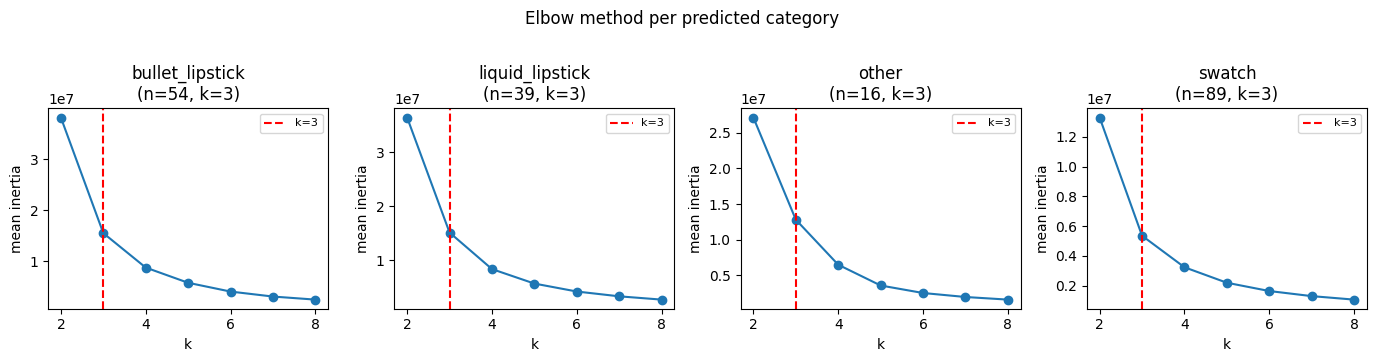

Optimal k per category: {'bullet_lipstick': 3, 'liquid_lipstick': 3, 'other': 3, 'swatch': 3}


In [5]:
K_RANGE = range(2, 9)

def optimal_k_for_group(img_paths, k_range=K_RANGE, seed=RANDOM_SEED):
    """Run elbow method on a list of image paths, return optimal k."""
    all_inertias = {k: [] for k in k_range}
    for path in img_paths:
        try:
            im = Image.open(path).convert('RGB')
            ar = np.asarray(im.resize((150, 150))).reshape(-1, 3).astype(float)
            for k in k_range:
                all_inertias[k].append(
                    KMeans(n_clusters=k, random_state=seed, n_init=10).fit(ar).inertia_
                )
        except Exception:
            continue
    mean_inertia = np.array([np.mean(all_inertias[k]) for k in k_range])
    d2 = np.diff(np.diff(mean_inertia))
    return list(k_range)[np.argmax(d2) + 1], mean_inertia

k_per_category = {}
fig, axes = plt.subplots(1, len(CLASSES), figsize=(14, 3.5))
for ax, cls in zip(axes, CLASSES):
    group = labels_df[labels_df['pred_label'] == cls]['img_path'].tolist()
    if not group:
        ax.set_title(f'{cls}\n(no images)')
        ax.axis('off')
        k_per_category[cls] = 3
        continue
    k_opt, mean_inertia = optimal_k_for_group(group)
    k_per_category[cls] = k_opt
    ax.plot(list(K_RANGE), mean_inertia, marker='o')
    ax.axvline(x=k_opt, color='red', linestyle='--', label=f'k={k_opt}')
    ax.set_title(f'{cls}\n(n={len(group)}, k={k_opt})')
    ax.set_xlabel('k'); ax.set_ylabel('mean inertia')
    ax.legend(fontsize=8)

plt.suptitle('Elbow method per predicted category', y=1.02)
plt.tight_layout()
plt.show()

print('Optimal k per category:', k_per_category)

# Color Extraction per Image

In [ ]:
import numpy as np
if not hasattr(np, 'asscalar'):
    np.asscalar = lambda a: a.item()

from colormath.color_objects import LabColor
from colormath.color_diff import delta_e_cie2000

def delta_e(pred_lab, true_lab):
    return delta_e_cie2000(LabColor(*pred_lab), LabColor(*true_lab))

def analyze_image_colors(image_path, num_clusters=3):
    im = Image.open(image_path).convert('RGB')
    im = im.resize((150, 150))
    ar = np.asarray(im).reshape(-1, 3).astype(float)

    codes, _ = scipy.cluster.vq.kmeans(ar, num_clusters)
    labels, _ = scipy.cluster.vq.vq(ar, codes)
    counts = np.bincount(labels)

    codes_lab = np.array([rgb2lab([[c / 255.0]])[0][0] for c in codes])

    mask = np.array([
        deltaE_ciede2000(lab, CIELAB_WHITE) >= BLACK_WHITE_THRESHOLD and
        deltaE_ciede2000(lab, CIELAB_BLACK) >= BLACK_WHITE_THRESHOLD
        for lab in codes_lab
    ])
    if not mask.any():
        mask = np.ones(len(codes), dtype=bool)

    filtered_lab    = codes_lab[mask]
    filtered_counts = counts[mask]
    mean_lab = np.mean(filtered_lab, axis=0)
    peak_lab = filtered_lab[np.argmax(filtered_counts)]
    return mean_lab, peak_lab

In [7]:
labels_df['mean_lab'] = None
labels_df['peak_lab'] = None
errors = {}

for i, row in labels_df.iterrows():
    k = k_per_category.get(row['pred_label'], 3)
    try:
        mean_lab, peak_lab = analyze_image_colors(row['img_path'], num_clusters=k)
        labels_df.at[i, 'mean_lab'] = list(mean_lab)
        labels_df.at[i, 'peak_lab'] = list(peak_lab)
    except Exception as e:
        errors[row['img_name_disk']] = str(e)

print(f'Processed: {labels_df["mean_lab"].notna().sum()} / {len(labels_df)}')
if errors:
    print(f'Errors ({len(errors)}):')
    for name, err in list(errors.items())[:5]:
        print(f'  {name}: {err}')

Processed: 0 / 198
Errors (198):
  lipstick__aboutface__paintit_matte_lip_color__night_sight.jpg: name 'analyze_image_colors' is not defined
  lipstick__anastasia_beverly_hills__liquid_lipstick__kathryn.jpg: name 'analyze_image_colors' is not defined
  lipstick__anastasia_beverly_hills__liquid_lipstick__reqiuem.jpg: name 'analyze_image_colors' is not defined
  lipstick__anastasia_beverly_hills__matte_lipstick__hollywood.jpg: name 'analyze_image_colors' is not defined
  lipstick__anastasia_beverly_hills__matte_lipstick__hush_pink.jpg: name 'analyze_image_colors' is not defined


In [ ]:
# Evaluation — Delta E vs Ground Truth

eval_df = labels_df[labels_df['true_L'].notna() & labels_df['mean_lab'].notna()].copy()

eval_df['de_mean'] = eval_df.apply(
    lambda r: delta_e(r['mean_lab'], [r['true_L'], r['true_a'], r['true_b']]), axis=1
)
eval_df['de_peak'] = eval_df.apply(
    lambda r: delta_e(r['peak_lab'], [r['true_L'], r['true_a'], r['true_b']]), axis=1
)

summary = eval_df.groupby('pred_label')[['de_mean', 'de_peak']].agg(['mean', 'median', 'count'])
summary.columns = ['mean ΔE (mean)', 'median ΔE (mean)', 'n (mean)', 'mean ΔE (peak)', 'median ΔE (peak)', 'n (peak)']
print('Delta E CIE 2000 — Model A v2 (per-category k-means)\n')
print(summary.round(2).to_string())
print(f'\nOverall mean ΔE — mean color: {eval_df["de_mean"].mean():.2f}  |  peak color: {eval_df["de_peak"].mean():.2f}')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, col, title in zip(axes, ['de_mean', 'de_peak'], ['Mean color', 'Peak color']):
    by_cat = eval_df.groupby('pred_label')[col].mean()
    by_cat.plot(kind='bar', ax=ax, color='#c97aa0', edgecolor='white')
    ax.axhline(2.3, color='gray', linestyle='--', linewidth=0.8, label='JND (2.3)')
    ax.set_title(f'Model A v2 — {title} Delta E by predicted category')
    ax.set_ylabel('Mean Delta E (CIE 2000)')
    ax.tick_params(axis='x', rotation=15)
    ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

### Why Delta E varies so much by product type

- **Swatch: peak works (ΔE ≈ 2):** The entire image is a flat color patch. The largest cluster by pixel count is the swatch color itself, so peak extraction nails it. Mean is worse because it blends the swatch with the white paper background.
- **Bullet / liquid: both strategies fail (ΔE ≈ 16–26):** The packaging dominates the image. Most pixels belong to the tube or container, not the lipstick color. K-means finds the biggest color regions, which are almost always the packaging. Neither mean nor peak can fix this without knowing *where* the lipstick color is.
- **Other: poor (ΔE ≈ 16–24):** Transparent containers mix the visible color with reflections, the container material, and the background. K-means picks up all of it indiscriminately. Small n (4 images) also makes the estimate noisy.

The core limitation of Model A: k-means works when the target color dominates the image (swatch), but fails when the lipstick color is a small region surrounded by packaging: which is the common case. Model C addresses this by using U-Net segmentation to isolate the color region before extraction.

# Model A v2 vs Model C: Direct Comparison

Model C uses the same Stage 1 classifier for routing, but then applies U-Net segmentation and type-specific extraction (median for swatch/bullet/liquid, dominant cluster for other) instead of global k-means.

Best strategy per category for Model A v2:
- `swatch`: peak color (largest cluster)
- `bullet_lipstick`, `liquid_lipstick`, `other`: mean color (average across non-background clusters)

In [ ]:
import segmentation_models_pytorch as smp
from skimage import color as skcolor

# ── Load segmenters ───────────────────────────────────────────────────────────
seg_tf = transforms.Compose([
    transforms.Resize((256, 256)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])

def build_segmenter():
    return smp.Unet(encoder_name='resnet18', encoder_weights=None, in_channels=3, classes=1)

def load_seg(ckpt_path):
    m = build_segmenter().to(DEVICE)
    m.load_state_dict(torch.load(ckpt_path, map_location=DEVICE)['model_state_dict'])
    m.eval()
    return m

seg      = load_seg(os.path.join(MODELS_DIR, 'unet_segmenter.pth'))
seg_other = load_seg(os.path.join(MODELS_DIR, 'unet_segmenter_other.pth'))
print('Segmenters loaded')

# ── Extraction functions ──────────────────────────────────────────────────────
SEG_CLASSES = {'bullet_lipstick', 'liquid_lipstick'}

def predict_mask(model, img_path, threshold=0.5):
    img = Image.open(img_path).convert('RGB')
    orig_w, orig_h = img.size
    x = seg_tf(img).unsqueeze(0).to(DEVICE)
    with torch.no_grad():
        prob = torch.sigmoid(model(x)).squeeze().cpu().numpy()
    mask = (prob > threshold).astype(np.uint8)
    return np.array(Image.fromarray(mask * 255).resize((orig_w, orig_h), Image.NEAREST)) // 255

def extract_swatch_color_c(img_rgb):
    lab = skcolor.rgb2lab(img_rgb / 255.0)
    L = lab[:, :, 0]
    fg = (L > 5) & (L < 95)
    if fg.sum() == 0:
        fg = np.ones_like(L, dtype=bool)
    return np.median(lab[fg], axis=0)

def extract_masked_color_c(img_rgb, mask_arr):
    lab = skcolor.rgb2lab(img_rgb / 255.0)
    pixels = lab[mask_arr == 1]
    return np.median(pixels, axis=0) if len(pixels) > 0 else np.full(3, np.nan)

def extract_dominant_cluster_c(img_rgb, mask_arr, k=3):
    lab = skcolor.rgb2lab(img_rgb / 255.0)
    pixels = lab[mask_arr == 1]
    if len(pixels) == 0:
        return np.full(3, np.nan)
    if len(pixels) < k:
        return np.median(pixels, axis=0)
    km = KMeans(n_clusters=k, random_state=RANDOM_SEED, n_init='auto')
    lbs = km.fit_predict(pixels)
    return km.cluster_centers_[np.bincount(lbs).argmax()]

# ── Run Model C on all labeled images ────────────────────────────────────────
c_rows = []
for _, row in labels_df.iterrows():
    img_path = row['img_path']
    pred     = row['pred_label']
    img      = np.array(Image.open(img_path).convert('RGB'))
    if pred == 'swatch':
        lab = extract_swatch_color_c(img)
    elif pred in SEG_CLASSES:
        mask = predict_mask(seg, img_path)
        lab  = extract_masked_color_c(img, mask)
    else:
        mask = predict_mask(seg_other, img_path)
        lab  = extract_dominant_cluster_c(img, mask)
    c_rows.append({'img_name': row['img_name'], 'c_L': lab[0], 'c_a': lab[1], 'c_b': lab[2]})

c_df = pd.DataFrame(c_rows)
labels_df = labels_df.merge(c_df, on='img_name', how='left')
print(f'Model C predictions: {labels_df["c_L"].notna().sum()} / {len(labels_df)}')

In [ ]:
# Best Model A per image: peak for swatch, mean for everything else
def best_a_lab(row):
    if row['pred_label'] == 'swatch':
        return row['peak_lab']
    return row['mean_lab']

cmp_df = labels_df[labels_df['true_L'].notna()].copy()
cmp_df['a_best_lab'] = cmp_df.apply(best_a_lab, axis=1)
cmp_df = cmp_df[cmp_df['a_best_lab'].notna() & cmp_df['c_L'].notna()].copy()

cmp_df['de_a'] = cmp_df.apply(
    lambda r: delta_e(r['a_best_lab'], [r['true_L'], r['true_a'], r['true_b']]), axis=1
)
cmp_df['de_c'] = cmp_df.apply(
    lambda r: delta_e([r['c_L'], r['c_a'], r['c_b']], [r['true_L'], r['true_a'], r['true_b']]), axis=1
)

comp = cmp_df.groupby('pred_label')[['de_a', 'de_c']].mean().round(2)
comp.columns = ['Model A v2', 'Model C']
print('Mean Delta E CIE 2000 — best of Model A v2 vs Model C\n')
print(comp.to_string())
print(f'\nOverall — Model A v2: {cmp_df["de_a"].mean():.2f}  |  Model C: {cmp_df["de_c"].mean():.2f}')

cats = comp.index.tolist()
x = np.arange(len(cats))
w = 0.35
fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(x - w/2, comp['Model A v2'], width=w, label='Model A v2 (k-means)', color='#bdc3c7', edgecolor='white')
ax.bar(x + w/2, comp['Model C'],    width=w, label='Model C (segmentation)', color='#c97aa0', edgecolor='white')
ax.set_xticks(x); ax.set_xticklabels(cats, rotation=15)
ax.set_ylabel('Mean Delta E (CIE 2000)')
ax.set_title('Model A v2 vs Model C — mean Delta E by category')
ax.axhline(2.3, color='gray', linestyle='--', linewidth=0.8, label='JND (2.3)')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

### Takeaway: K-means clusting wins for swatches

For swatches, k-means clustering achieves a mean ΔE of **2.16** vs Model C's **3.15**: comfortably below the just-noticeable-difference threshold of 2.3, and better than the segmentation-based approach. This makes sense: a swatch image is almost entirely the lipstick color itself, so the largest k-means cluster captures it directly without any need for segmentation. Model C's extra stages (U-Net inference, mask-based extraction) add complexity without adding accuracy here.

This points to a practical hybrid strategy: use **k-means peak** for swatches and **segmentation** for bullet, liquid, and closed product types. Clustering requires no mask annotations and no segmentation model, just the raw image, making it significantly cheaper to maintain and scale for the swatch category.

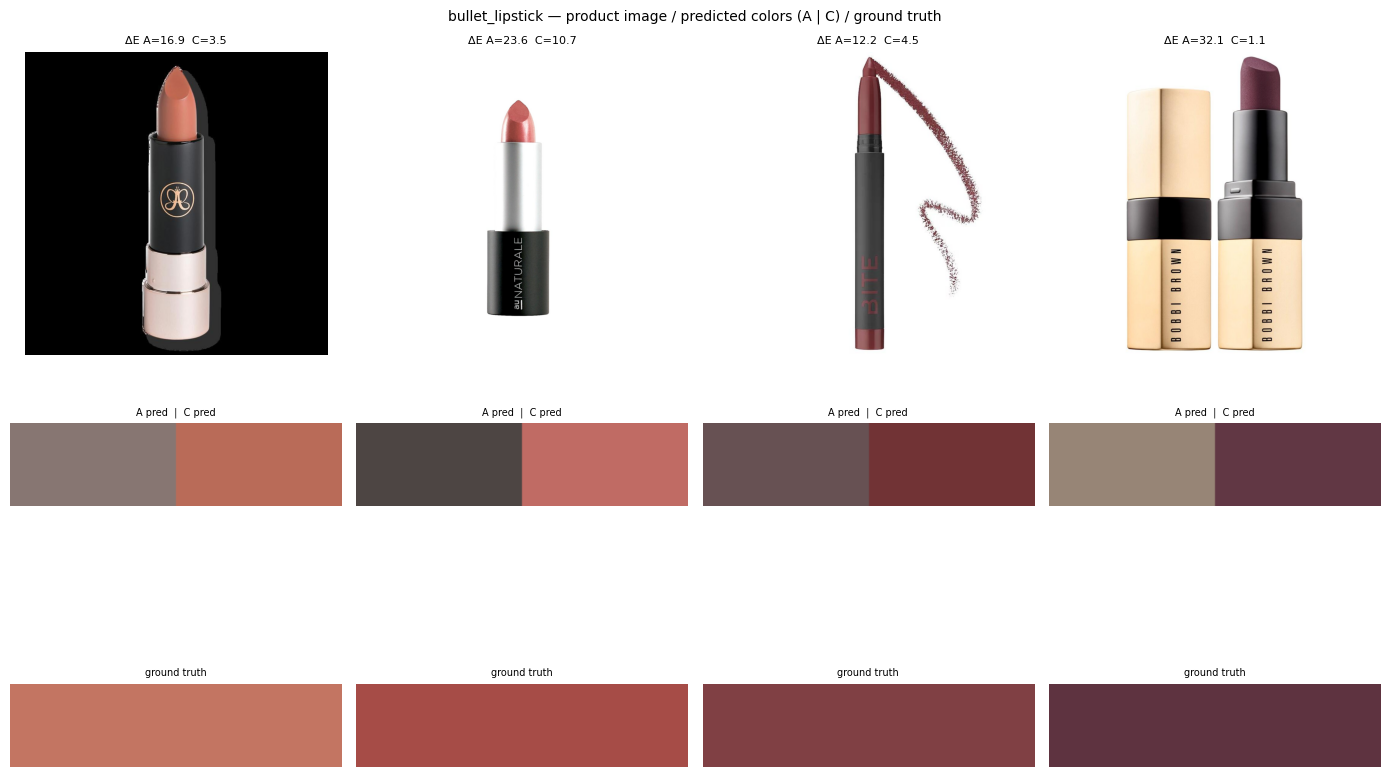

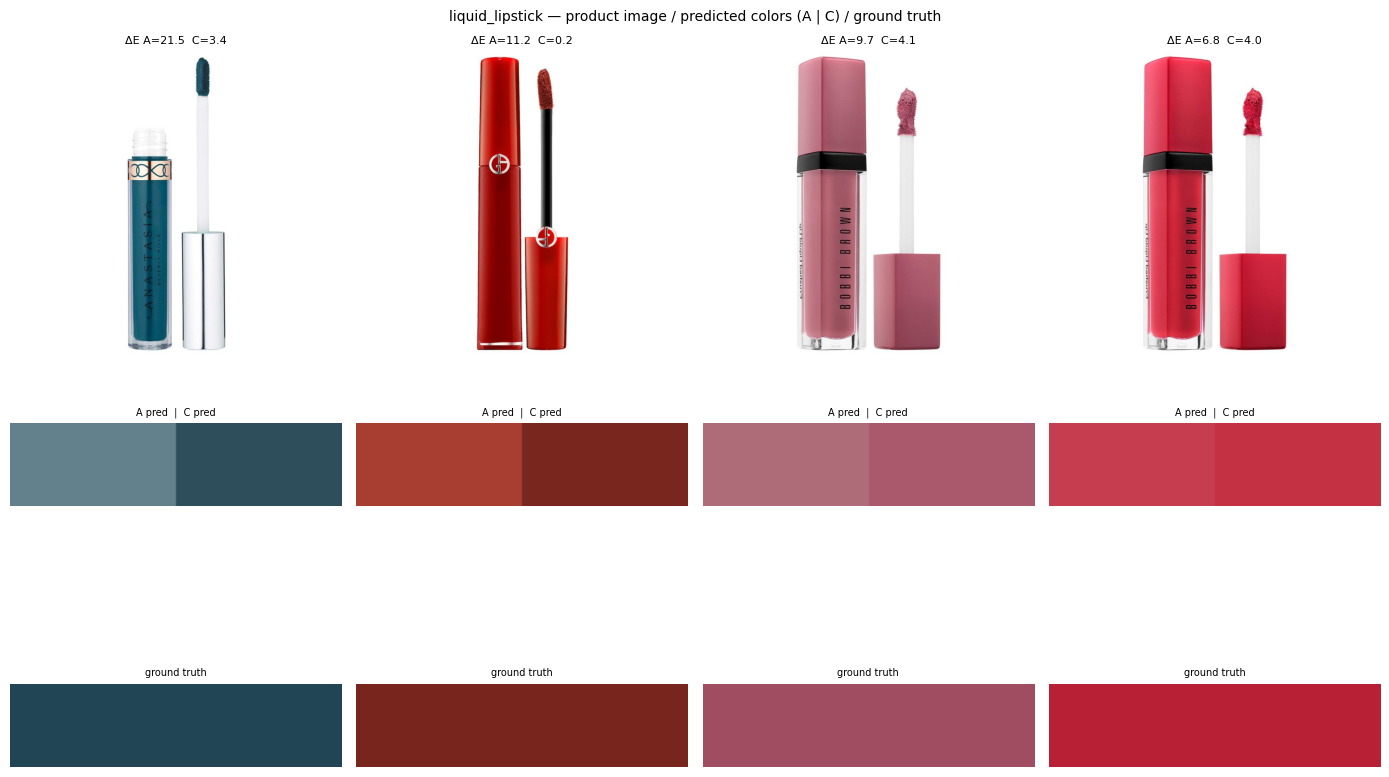

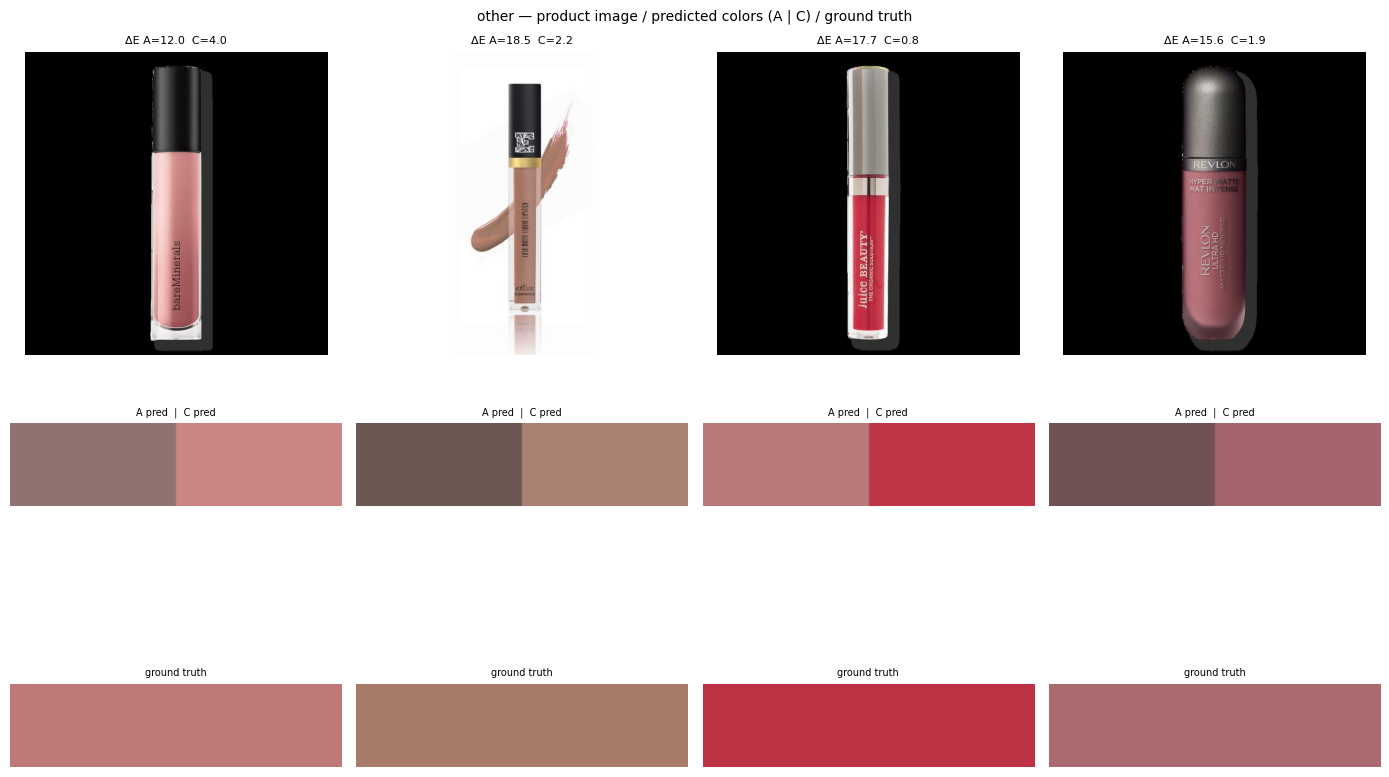

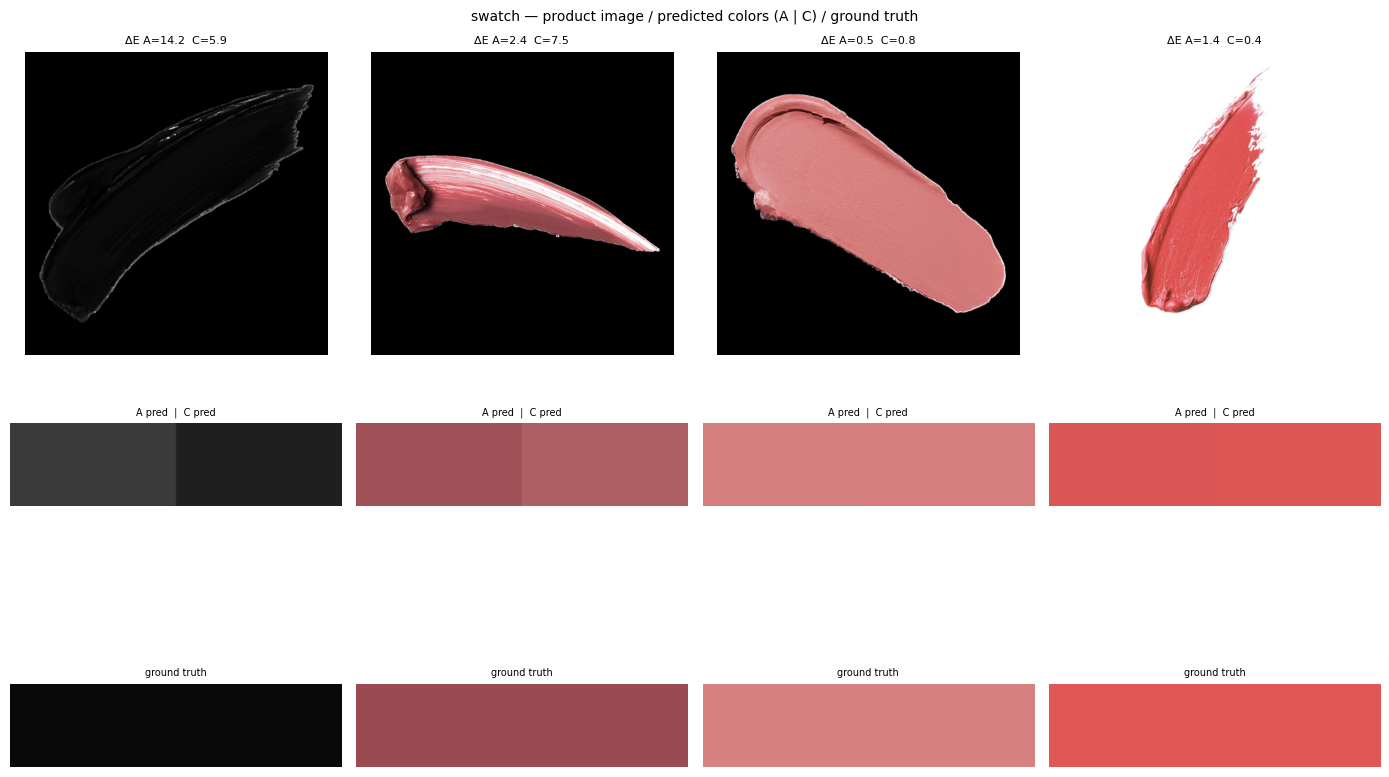

In [15]:
def lab_swatch(L, a, b, w=80, h=40):
    rgb = skcolor.lab2rgb(np.array([[[L, a, b]]])).clip(0, 1)
    return np.ones((h, w, 3), dtype=np.float32) * rgb[0, 0]

n_show = 4

for cls in CLASSES:
    grp = cmp_df[cmp_df['pred_label'] == cls].head(n_show).reset_index(drop=True)
    if grp.empty:
        continue

    fig, axes = plt.subplots(3, len(grp), figsize=(len(grp) * 3.5, 9))
    if len(grp) == 1:
        axes = axes.reshape(3, 1)

    for i, row in grp.iterrows():
        img = np.array(Image.open(row['img_path']).convert('RGB'))

        # row 0: product image
        axes[0, i].imshow(img)
        axes[0, i].set_title(f"ΔE A={row['de_a']:.1f}  C={row['de_c']:.1f}", fontsize=8)
        axes[0, i].axis('off')

        # row 1: Model A pred swatch | Model C pred swatch
        a_sw = lab_swatch(*row['a_best_lab'])
        c_sw = lab_swatch(row['c_L'], row['c_a'], row['c_b'])
        axes[1, i].imshow(np.concatenate([a_sw, c_sw], axis=1))
        axes[1, i].set_title('A pred  |  C pred', fontsize=7)
        axes[1, i].axis('off')

        # row 2: ground truth swatch
        gt_sw = lab_swatch(row['true_L'], row['true_a'], row['true_b'])
        axes[2, i].imshow(np.concatenate([gt_sw, gt_sw], axis=1))
        axes[2, i].set_title('ground truth', fontsize=7)
        axes[2, i].axis('off')

    fig.suptitle(f'{cls} — product image / predicted colors (A | C) / ground truth', fontsize=10)
    plt.tight_layout()
    plt.show()